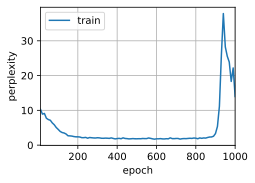

In [3]:
import torch
import math
from d2l import torch as d2l
from utils import load_data_time_machine
from torch import nn
from models import RNNModel,predict_rnn,grad_clipping

def train_rnn(net, train_iter, vocab, lr, num_epochs, device,
              use_random_iter=False):
    """训练模型"""
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', ylabel='perplexity',
                            legend=['train'], xlim=[10, num_epochs])
    # 初始化
    updater = torch.optim.SGD(net.parameters(), lr)
    predict = lambda prefix: predict_rnn(prefix, 100, net, vocab, device)
    # 训练和预测
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_rnn(
            net, train_iter, loss, updater, device, use_random_iter)
        if (epoch + 1) % 10 == 0:
            # print(predict('time traveller'))
            animator.add(epoch + 1, [ppl])
    print(f'困惑度 {ppl:.1f}, {speed:.1f} 词元/秒 {str(device)}')
    print(predict('time traveller'))
    print(predict('traveller'))


def train_epoch_rnn(net, train_iter, loss, updater, device, use_random_iter):
    """训练网络一个迭代周期"""
    state, timer = None, d2l.Timer()
    metric = d2l.Accumulator(2)  # 训练损失之和,词元数量
    for X, Y in train_iter:
        # 在第一次迭代或使用随机抽样时初始化state
        state = net.begin_state(batch_size=X.shape[0], device=device)
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net, 1)
            updater.step()
        else:
            l.backward()
            grad_clipping(net, 1)
            # 因为已经调用了mean函数
            updater(batch_size=1)
        metric.add(l * y.numel(), y.numel())
    return math.exp(metric[0] / metric[1]), metric[1] / timer.stop()


if __name__ == '__main__':
    # 初始化批次和每个批次内每条数据的长度
    batch_size, num_steps = 32, 35
    train_iter, vocab = load_data_time_machine(batch_size, num_steps)

    num_hiddens = 256
    rnn_layer = nn.RNN(len(vocab), num_hiddens)

    # 选择设备
    device = d2l.try_gpu()
    net = RNNModel(rnn_layer, vocab_size=len(vocab))
    net = net.to(device)

    # 训练
    num_epochs, lr = 1000, 1.5
    train_rnn(net, train_iter, vocab, lr, num_epochs, device)

